# NSL-KDD Intrusion Detection System
## KDDTrain+ Only (80/20 Split)

**Feature Selection Methods:** Variance Threshold · Pearson Correlation · ANOVA F-Score · PCA  
**Models:** Random Forest · SVM · XGBoost · MLP  
**Tuning:** GridSearchCV for highest model accuracy

## 1. Imports & Setup

In [2]:
import warnings
import os
import time

warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import VarianceThreshold, f_classif, SelectKBest
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
from sklearn.base import clone

from xgboost import XGBClassifier

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input

print("All imports successful.")
print(f"TensorFlow: {tf.__version__}")

All imports successful.
TensorFlow: 2.21.0


## 2. Data Loading & Splitting

In [3]:
col_names = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes",
    "land","wrong_fragment","urgent","hot","num_failed_logins","logged_in",
    "num_compromised","root_shell","su_attempted","num_root","num_file_creations",
    "num_shells","num_access_files","num_outbound_cmds","is_host_login",
    "is_guest_login","count","srv_count","serror_rate","srv_serror_rate",
    "rerror_rate","srv_rerror_rate","same_srv_rate","diff_srv_rate",
    "srv_diff_host_rate","dst_host_count","dst_host_srv_count",
    "dst_host_same_srv_rate","dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate","dst_host_srv_diff_host_rate",
    "dst_host_serror_rate","dst_host_srv_serror_rate",
    "dst_host_rerror_rate","dst_host_srv_rerror_rate",
    "label","level"
]

data = pd.read_csv("data/KDDTrain+.txt", header=None, names=col_names)
print("Full KDDTrain+ shape:", data.shape)

# 80/20 stratified split
_y_tmp = data["label"]
train_idx, test_idx = train_test_split(
    data.index, test_size=0.2, random_state=42, stratify=_y_tmp
)
data      = data.loc[train_idx].reset_index(drop=True)
test_data = data.loc[test_idx].reset_index(drop=True) if False else \
            pd.read_csv("data/KDDTrain+.txt", header=None, names=col_names).loc[test_idx].reset_index(drop=True)

print(f"Train: {data.shape}  |  Test: {test_data.shape}")

Full KDDTrain+ shape: (125973, 43)
Train: (100778, 43)  |  Test: (25195, 43)


## 3. Exploratory Data Analysis

In [4]:
print(f"Shape: {data.shape}")
print(f"Missing values: {data.isnull().sum().sum()}")
print(f"Duplicate rows: {data.duplicated().sum()}")
print("\nLabel distribution (train):")
print(data['label'].value_counts())

Shape: (100778, 43)
Missing values: 0
Duplicate rows: 0

Label distribution (train):
label
normal             53874
neptune            32971
satan               2906
ipsweep             2879
portsweep           2345
smurf               2117
nmap                1194
back                 765
teardrop             714
warezclient          712
pod                  161
guess_passwd          42
buffer_overflow       24
warezmaster           16
land                  14
imap                   9
rootkit                8
loadmodule             7
multihop               6
ftp_write              6
perl                   3
phf                    3
spy                    2
Name: count, dtype: int64


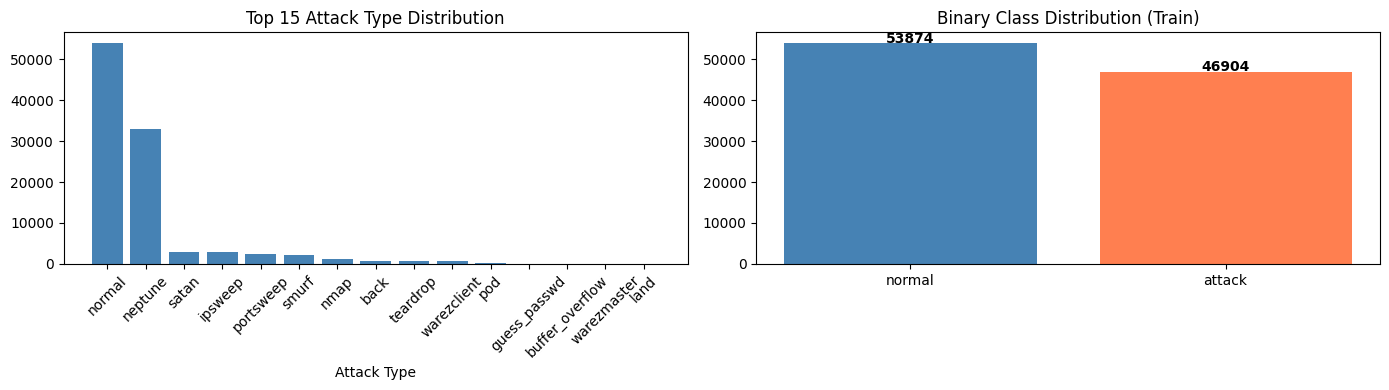

In [5]:
# Class distribution plots
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Attack type distribution
top_labels = data['label'].value_counts().head(15)
axes[0].bar(top_labels.index, top_labels.values, color='steelblue')
axes[0].set_title('Top 15 Attack Type Distribution')
axes[0].set_xlabel('Attack Type')
axes[0].tick_params(axis='x', rotation=45)

# Binary: normal vs attack
binary_counts = data['label'].apply(lambda x: 'normal' if x == 'normal' else 'attack').value_counts()
axes[1].bar(binary_counts.index, binary_counts.values, color=['steelblue', 'coral'])
axes[1].set_title('Binary Class Distribution (Train)')
for i, v in enumerate(binary_counts.values):
    axes[1].text(i, v + 100, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 4. Preprocessing

In [6]:
df      = data.copy()
test_df = test_data.copy()

# Drop constant/redundant columns
df.drop(["num_outbound_cmds", "level"], axis=1, inplace=True)
test_df.drop(["num_outbound_cmds", "level"], axis=1, inplace=True)

# Binary labels: 0 = normal, 1 = attack
df["binary_label"]      = df["label"].apply(lambda x: 0 if x == "normal" else 1)
test_df["binary_label"] = test_df["label"].apply(lambda x: 0 if x == "normal" else 1)

# Split features / labels
cat_cols = ["protocol_type", "service", "flag"]
X_train_raw = df.drop(columns=["label", "binary_label"])
y_train     = df["binary_label"]
X_test_raw  = test_df.drop(columns=["label", "binary_label"])
y_test      = test_df["binary_label"]

numeric_raw_cols = [c for c in X_train_raw.columns if c not in cat_cols]

# One-Hot Encode categorical features (fit ONLY on train)
ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
col_transformer = ColumnTransformer(
    transformers=[
        ("ohe", ohe, cat_cols),
        ("passthrough", "passthrough", numeric_raw_cols)
    ]
)
X_train = col_transformer.fit_transform(X_train_raw)
X_test  = col_transformer.transform(X_test_raw)

ohe_feature_names = col_transformer.named_transformers_['ohe'].get_feature_names_out(cat_cols).tolist()
all_feature_names = ohe_feature_names + numeric_raw_cols
X_train = pd.DataFrame(X_train, columns=all_feature_names)
X_test  = pd.DataFrame(X_test,  columns=all_feature_names)

print(f"X_train: {X_train.shape}  X_test: {X_test.shape}")
print(f"y_train — 0:{(y_train==0).sum()}  1:{(y_train==1).sum()}")

X_train: (100778, 120)  X_test: (25195, 120)
y_train — 0:53874  1:46904


In [7]:
# Log1p transform for highly skewed numeric features
ohe_cols_set      = set(ohe_feature_names)
numeric_only_cols = [c for c in X_train.columns if c not in ohe_cols_set]
skewness          = X_train[numeric_only_cols].skew()
high_skew_cols    = skewness[skewness > 0.75].index.tolist()

X_train_log = X_train.copy()
X_test_log  = X_test.copy()
for col in high_skew_cols:
    if (X_train_log[col] >= 0).all() and (X_test_log[col] >= 0).all():
        X_train_log[col] = np.log1p(X_train_log[col])
        X_test_log[col]  = np.log1p(X_test_log[col])

# Standard scaling
scaler         = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_log),
    columns=X_train_log.columns
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_log),
    columns=X_test_log.columns
)

feature_names = np.array(X_train_scaled.columns.tolist())
print(f"Skewed columns log-transformed: {len(high_skew_cols)}")
print(f"Final feature count: {len(feature_names)}")

Skewed columns log-transformed: 32
Final feature count: 120


## 5. Feature Selection

Four methods are applied. All selectors are **fit exclusively on training data** to prevent data leakage.

In [8]:
# ── 5.1 Variance Threshold ────────────────────────────────────────
vt = VarianceThreshold(threshold=0.01)
X_tr_vt = vt.fit_transform(X_train_log)
X_te_vt = vt.transform(X_test_log)
vt_features = X_train_log.columns[vt.get_support()]

print(f"Variance Threshold → kept {X_tr_vt.shape[1]} / {len(feature_names)} features")
print(f"Removed: {list(X_train_log.columns[~vt.get_support()])}")

Variance Threshold → kept 45 / 120 features
Removed: ['service_IRC', 'service_X11', 'service_Z39_50', 'service_aol', 'service_auth', 'service_bgp', 'service_courier', 'service_csnet_ns', 'service_ctf', 'service_daytime', 'service_discard', 'service_domain', 'service_echo', 'service_efs', 'service_exec', 'service_gopher', 'service_harvest', 'service_hostnames', 'service_http_443', 'service_http_8001', 'service_imap4', 'service_iso_tsap', 'service_klogin', 'service_kshell', 'service_ldap', 'service_link', 'service_login', 'service_mtp', 'service_name', 'service_netbios_dgm', 'service_netbios_ns', 'service_netbios_ssn', 'service_netstat', 'service_nnsp', 'service_nntp', 'service_ntp_u', 'service_pm_dump', 'service_pop_2', 'service_pop_3', 'service_printer', 'service_red_i', 'service_remote_job', 'service_rje', 'service_shell', 'service_sql_net', 'service_ssh', 'service_sunrpc', 'service_supdup', 'service_systat', 'service_tftp_u', 'service_tim_i', 'service_time', 'service_urh_i', 'service

Pearson Correlation → kept 113 features
Dropped (|r| > 0.90): ['serror_rate', 'srv_serror_rate', 'srv_rerror_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate']


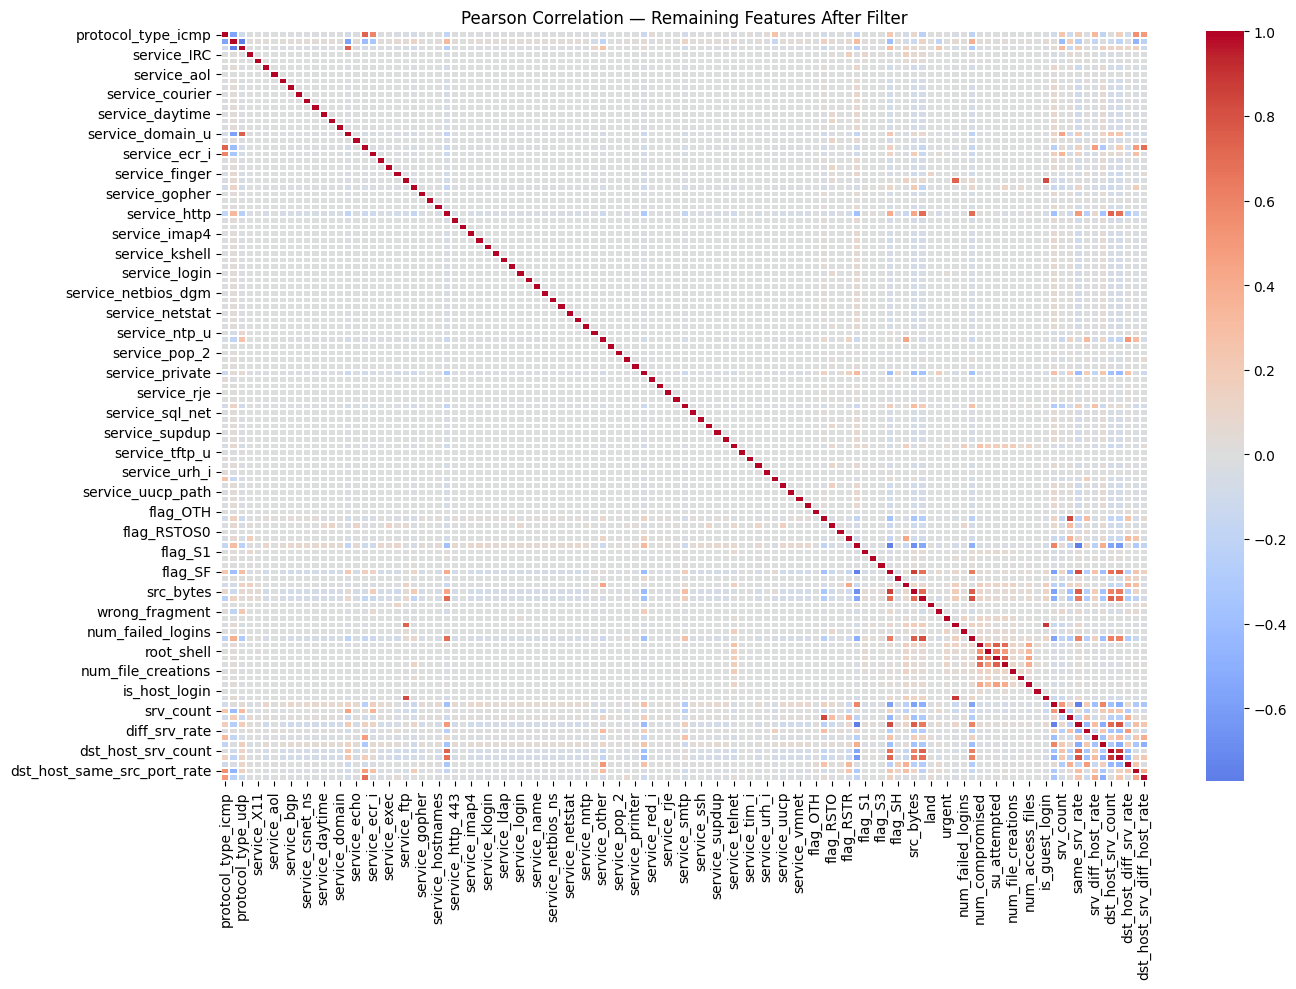

In [9]:
# ── 5.2 Pearson Correlation Filter ───────────────────────────────
corr_mat  = X_train_log.corr().abs()
upper     = corr_mat.where(np.triu(np.ones(corr_mat.shape), k=1).astype(bool))
drop_corr = [c for c in upper.columns if any(upper[c] > 0.90)]

X_tr_pc = X_train_log.drop(columns=drop_corr)
X_te_pc = X_test_log.drop(columns=drop_corr)
pc_features = np.array(X_tr_pc.columns.tolist())

print(f"Pearson Correlation → kept {X_tr_pc.shape[1]} features")
print(f"Dropped (|r| > 0.90): {drop_corr}")

# Correlation heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(X_tr_pc.corr(), cmap="coolwarm", center=0, linewidths=0.3, annot=False)
plt.title("Pearson Correlation — Remaining Features After Filter")
plt.tight_layout()
plt.show()

In [12]:
# ── 5.3 ANOVA F-Score ────────────────────────────────────────────
f_scores, f_pvals = f_classif(X_train_scaled, y_train)

# Keep features with p <= 0.05, then select top-K by median F threshold
sig_mask     = f_pvals <= 0.05
sig_f_scores = f_scores[sig_mask]
sig_features = feature_names[sig_mask]
f_median     = np.median(sig_f_scores)
top_mask     = sig_f_scores >= f_median
anova_k      = int(top_mask.sum())

sel_anova  = SelectKBest(f_classif, k=anova_k)
X_tr_anova = sel_anova.fit_transform(X_train_scaled, y_train)
X_te_anova = sel_anova.transform(X_test_scaled)

print(f"ANOVA F-Score → kept {anova_k} features (p≤0.05, F≥median {f_median:.1f})")
print(f"Selected Features: {sig_features[top_mask].tolist()}")


ANOVA F-Score → kept 54 features (p≤0.05, F≥median 459.3)
Selected Features: ['protocol_type_icmp', 'protocol_type_udp', 'service_Z39_50', 'service_bgp', 'service_courier', 'service_csnet_ns', 'service_ctf', 'service_daytime', 'service_discard', 'service_domain_u', 'service_eco_i', 'service_ecr_i', 'service_efs', 'service_ftp_data', 'service_gopher', 'service_http', 'service_http_443', 'service_imap4', 'service_iso_tsap', 'service_nnsp', 'service_private', 'service_smtp', 'service_supdup', 'service_uucp', 'service_uucp_path', 'service_vmnet', 'service_whois', 'flag_REJ', 'flag_RSTO', 'flag_RSTR', 'flag_S0', 'flag_SF', 'duration', 'src_bytes', 'dst_bytes', 'wrong_fragment', 'logged_in', 'count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate

PCA 95% variance → 86 components, shape: (100778, 86)
PCA k=20          → shape: (100778, 20)


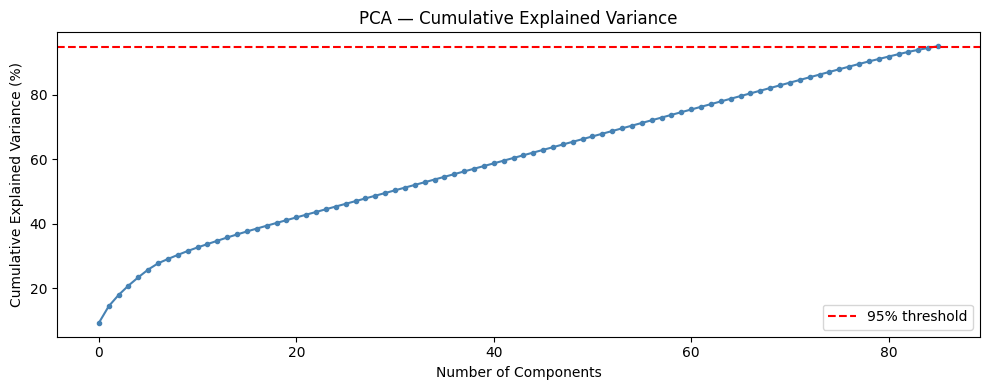

In [10]:
# ── 5.4 PCA ──────────────────────────────────────────────────────
# 95% variance variant
pca_95     = PCA(n_components=0.95, random_state=42)
X_tr_pca95 = pca_95.fit_transform(X_train_scaled)
X_te_pca95 = pca_95.transform(X_test_scaled)

# Fixed k=20 variant
pca_20     = PCA(n_components=20, random_state=42)
X_tr_pca20 = pca_20.fit_transform(X_train_scaled)
X_te_pca20 = pca_20.transform(X_test_scaled)

print(f"PCA 95% variance → {pca_95.n_components_} components, shape: {X_tr_pca95.shape}")
print(f"PCA k=20          → shape: {X_tr_pca20.shape}")

# Explained variance plot
plt.figure(figsize=(10, 4))
plt.plot(np.cumsum(pca_95.explained_variance_ratio_) * 100,
         marker="o", markersize=3, color="steelblue")
plt.axhline(95, color="red", linestyle="--", label="95% threshold")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance (%)")
plt.title("PCA — Cumulative Explained Variance")
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
# Feature sets dictionary — only the 4 required methods
feature_sets = {
    "01_variance_thresh": (X_tr_vt,        X_te_vt),
    "02_pearson_corr":    (X_tr_pc,        X_te_pc),
    "03_anova_f":         (X_tr_anova,     X_te_anova),
    "04_pca_95pct":       (X_tr_pca95,     X_te_pca95),
    "05_pca_k20":         (X_tr_pca20,     X_te_pca20),
}

print(f"{'Feature Set':<22}  Train Shape      Test Shape")
print("-" * 55)
for name, (Xtr, Xte) in feature_sets.items():
    print(f"{name:<22}  {str(np.array(Xtr).shape):<16}  {np.array(Xte).shape}")

Feature Set             Train Shape      Test Shape
-------------------------------------------------------
01_variance_thresh      (100778, 45)      (25195, 45)
02_pearson_corr         (100778, 113)     (25195, 113)
03_anova_f              (100778, 54)      (25195, 54)
04_pca_95pct            (100778, 86)      (25195, 86)
05_pca_k20              (100778, 20)      (25195, 20)


## 6. Model Definitions (From Paper)

| Model | Key Parameters |
|-------|---------------|
| **RF** | n_estimators=200, max_depth=20, random_state=50 |
| **SVM** | C=1.0, kernel='rbf', degree=3, gamma='scale' |
| **XGBoost** | n_estimators=200, max_depth=6, lr=0.1 |
| **MLP** | Dense(300→200→100, relu) → Dropout(0.5) → Softmax(2) |

In [12]:
# Random Forest
model_RF = RandomForestClassifier(
    n_estimators = 200,
    max_depth    = 20,
    random_state = 50,
    n_jobs       = -1,
    class_weight = "balanced"
)

# SVM
model_SVM = SVC(
    C           = 1.0,
    kernel      = "rbf",
    degree      = 3,
    gamma       = "scale",
    probability = True,
    random_state= 42,
    class_weight= "balanced"
)

# XGBoost
try:
    import subprocess
    subprocess.check_output(["nvidia-smi"], timeout=3)
    xgb_device = "cuda"
except Exception:
    xgb_device = "cpu"

model_XGB = XGBClassifier(
    n_estimators      = 200,
    max_depth         = 6,
    learning_rate     = 0.1,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    random_state      = 42,
    eval_metric       = "logloss",
    device            = xgb_device,
    n_jobs            = 1
)
print(f"XGBoost device: {xgb_device}")

# MLP Builder
def build_mlp(input_dim):
    """
    Dense(300, relu) → BN → Dense(200, relu) → BN → Dense(100, relu)
    → Dropout(0.5) → Dense(2, softmax)
    """
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(300, activation="relu"),
        BatchNormalization(),
        Dense(200, activation="relu"),
        BatchNormalization(),
        Dense(100, activation="relu"),
        Dropout(0.5),
        Dense(2,   activation="softmax")
    ])
    model.compile(
        optimizer = "adam",
        loss      = "sparse_categorical_crossentropy",
        metrics   = ["accuracy"]
    )
    return model

build_mlp(10).summary()

XGBoost device: cuda


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 300)            │         3,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 300)            │         1,200 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 200)            │        60,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 200)            │           800 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │        20,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           202 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 85,802 (335.16 KB)

 Trainable params: 84,802 (331.26 KB)

 Non-trainable params: 1,000 (3.91 KB)

## 7. Evaluation Helper

In [25]:
def evaluate(y_true, y_pred, y_prob=None):
    metrics = {
        "accuracy"   : round(accuracy_score(y_true, y_pred), 4),
        "precision"  : round(precision_score(y_true, y_pred, average="weighted", zero_division=0), 4),
        "recall"     : round(recall_score(y_true, y_pred, average="weighted", zero_division=0), 4),
        "f1_weighted": round(f1_score(y_true, y_pred, average="weighted", zero_division=0), 4),
        "f1_macro"   : round(f1_score(y_true, y_pred, average="macro", zero_division=0), 4),
    }
    if y_prob is not None:
        prob = y_prob[:, 1] if y_prob.ndim == 2 else y_prob
        try:
            metrics["roc_auc"] = round(roc_auc_score(y_true, prob), 4)
        except Exception:
            metrics["roc_auc"] = None
    else:
        metrics["roc_auc"] = None
    return metrics

## 8. Training & Evaluation Loop

In [14]:
results         = []
best_estimators = {fs: {} for fs in feature_sets}
SVM_MAX_ROWS    = 30_000   # SVM subsample for speed

for fs_name, (X_tr, X_te) in feature_sets.items():
    X_tr = np.array(X_tr)
    X_te = np.array(X_te)
    print(f"\n{'='*60}")
    print(f"Feature Set: {fs_name}  |  shape: {X_tr.shape}")
    print('='*60)

    # ── RF ───────────────────────────────────────────────────────
    print("[RF]")
    t0 = time.time()
    m  = clone(model_RF)
    m.fit(X_tr, y_train)
    yp   = m.predict(X_te)
    yprb = m.predict_proba(X_te)
    met  = evaluate(y_test, yp, yprb)
    elapsed = round(time.time() - t0, 2)
    print(f"  acc={met['accuracy']}  f1={met['f1_weighted']}  roc={met['roc_auc']}  ({elapsed}s)")
    results.append({"feature_set": fs_name, "model": "RF", "time_s": elapsed, **met})
    best_estimators[fs_name]["RF"] = m

    # ── SVM ──────────────────────────────────────────────────────
    print("[SVM]")
    t0  = time.time()
    m   = clone(model_SVM)
    idx = np.random.default_rng(42).choice(len(X_tr), min(SVM_MAX_ROWS, len(X_tr)), replace=False)
    m.fit(X_tr[idx], y_train.iloc[idx])
    yp   = m.predict(X_te)
    yprb = m.predict_proba(X_te)
    met  = evaluate(y_test, yp, yprb)
    elapsed = round(time.time() - t0, 2)
    print(f"  acc={met['accuracy']}  f1={met['f1_weighted']}  roc={met['roc_auc']}  ({elapsed}s)")
    results.append({"feature_set": fs_name, "model": "SVM", "time_s": elapsed, **met})
    best_estimators[fs_name]["SVM"] = m

    # ── XGBoost ──────────────────────────────────────────────────
    print("[XGB]")
    t0 = time.time()
    m  = clone(model_XGB)
    m.fit(X_tr, y_train)
    yp   = m.predict(X_te)
    yprb = m.predict_proba(X_te)
    met  = evaluate(y_test, yp, yprb)
    elapsed = round(time.time() - t0, 2)
    print(f"  acc={met['accuracy']}  f1={met['f1_weighted']}  roc={met['roc_auc']}  ({elapsed}s)")
    results.append({"feature_set": fs_name, "model": "XGB", "time_s": elapsed, **met})
    best_estimators[fs_name]["XGB"] = m

    # ── MLP ──────────────────────────────────────────────────────
    print("[MLP]")
    t0 = time.time()
    mlp = build_mlp(X_tr.shape[1])
    mlp.fit(
        X_tr, y_train,
        validation_split = 0.1,
        epochs           = 20,
        batch_size       = 256,
        callbacks        = [tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)],
        verbose          = 0
    )
    yp   = np.argmax(mlp.predict(X_te, verbose=0), axis=1)
    yprb = mlp.predict(X_te, verbose=0)
    met  = evaluate(y_test, yp, yprb)
    elapsed = round(time.time() - t0, 2)
    print(f"  acc={met['accuracy']}  f1={met['f1_weighted']}  roc={met['roc_auc']}  ({elapsed}s)")
    results.append({"feature_set": fs_name, "model": "MLP", "time_s": elapsed, **met})
    best_estimators[fs_name]["MLP"] = mlp

print("\nTraining complete.")


Feature Set: 01_variance_thresh  |  shape: (100778, 45)
[RF]
  acc=0.9987  f1=0.9987  roc=1.0  (6.4s)
[SVM]
  acc=0.9361  f1=0.9361  roc=0.9762  (210.07s)
[XGB]
  acc=0.9989  f1=0.9989  roc=1.0  (1.45s)
[MLP]
  acc=0.9943  f1=0.9943  roc=0.9996  (13.12s)

Feature Set: 02_pearson_corr  |  shape: (100778, 113)
[RF]
  acc=0.9985  f1=0.9985  roc=1.0  (8.16s)
[SVM]
  acc=0.9355  f1=0.9355  roc=0.9762  (346.06s)
[XGB]
  acc=0.9988  f1=0.9988  roc=1.0  (2.63s)
[MLP]
  acc=0.9944  f1=0.9944  roc=0.9997  (18.56s)

Feature Set: 03_anova_f  |  shape: (100778, 54)
[RF]
  acc=0.9985  f1=0.9985  roc=1.0  (5.79s)
[SVM]
  acc=0.9931  f1=0.9931  roc=0.9989  (35.83s)
[XGB]
  acc=0.9988  f1=0.9988  roc=1.0  (1.72s)
[MLP]
  acc=0.9963  f1=0.9963  roc=0.9999  (22.1s)

Feature Set: 04_pca_95pct  |  shape: (100778, 86)
[RF]
  acc=0.9979  f1=0.9979  roc=1.0  (38.38s)
[SVM]
  acc=0.9897  f1=0.9897  roc=0.9984  (59.7s)
[XGB]
  acc=0.9983  f1=0.9983  roc=1.0  (3.22s)
[MLP]
  acc=0.9955  f1=0.9955  roc=0.9999  (

## 9. Results Comparison

In [15]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(["accuracy", "f1_weighted"], ascending=False).reset_index(drop=True)

print("All Results — sorted by Accuracy:")
display(results_df[["feature_set","model","accuracy","f1_weighted","f1_macro","roc_auc","time_s"]])

print("\nBest result per model:")
display(
    results_df.groupby("model")
              .apply(lambda g: g.nlargest(1, "accuracy"))
              .reset_index(drop=True)[["model","feature_set","accuracy","f1_weighted","roc_auc"]]
)

All Results — sorted by Accuracy:


,feature_set,model,accuracy,f1_weighted,f1_macro,roc_auc,time_s
0,01_variance_thresh,XGB,0.9989,0.9989,0.9989,1.0000,1.45
1,02_pearson_corr,XGB,0.9988,0.9988,0.9988,1.0000,2.63
2,03_anova_f,XGB,0.9988,0.9988,0.9988,1.0000,1.72
3,01_variance_thresh,RF,0.9987,0.9987,0.9987,1.0000,6.40
4,02_pearson_corr,RF,0.9985,0.9985,0.9985,1.0000,8.16
5,03_anova_f,RF,0.9985,0.9985,0.9985,1.0000,5.79
6,04_pca_95pct,XGB,0.9983,0.9983,0.9983,1.0000,3.22
7,05_pca_k20,XGB,0.9980,0.9980,0.9980,1.0000,1.31
8,04_pca_95pct,RF,0.9979,0.9979,0.9979,1.0000,38.38
9,05_pca_k20,RF,0.9979,0.9979,0.9978,0.9999,14.89



Best result per model:


,model,feature_set,accuracy,f1_weighted,roc_auc
0,MLP,03_anova_f,0.9963,0.9963,0.9999
1,RF,01_variance_thresh,0.9987,0.9987,1.0000
2,SVM,05_pca_k20,0.9950,0.9950,0.9984
3,XGB,01_variance_thresh,0.9989,0.9989,1.0000


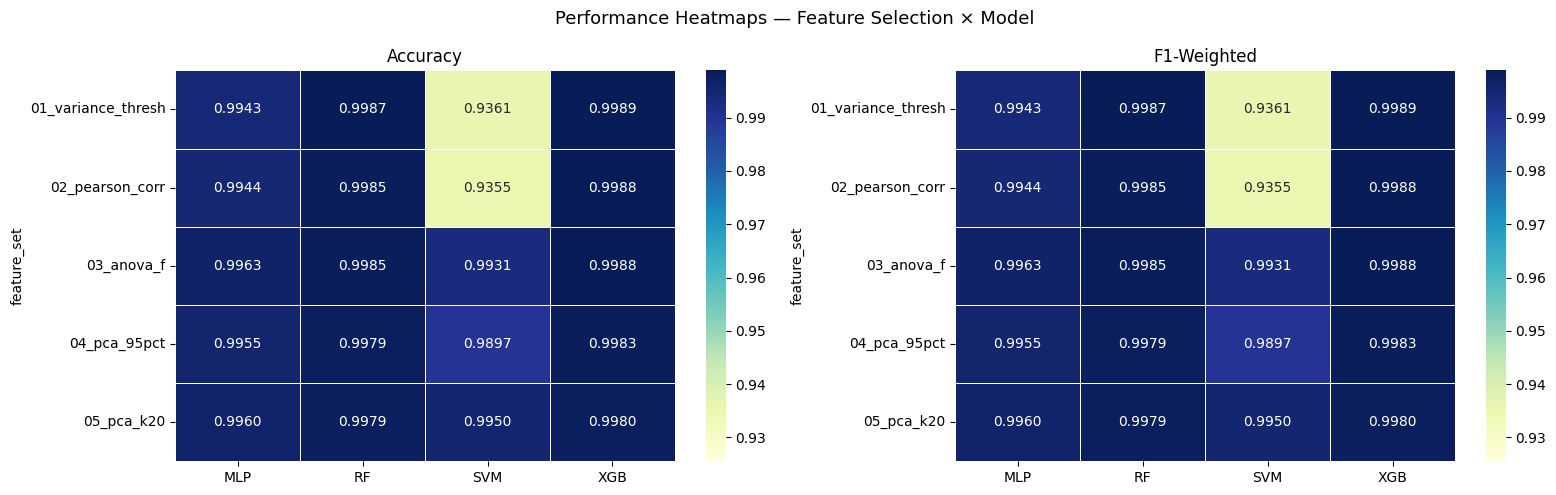

In [16]:
# ── Heatmap: Accuracy across Feature Sets × Models
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

heat_acc = results_df.pivot_table(index="feature_set", columns="model", values="accuracy")
sns.heatmap(heat_acc, annot=True, fmt=".4f", cmap="YlGnBu", ax=axes[0],
            linewidths=0.5, vmin=heat_acc.values.min() - 0.01)
axes[0].set_title("Accuracy")
axes[0].set_xlabel("")

heat_f1 = results_df.pivot_table(index="feature_set", columns="model", values="f1_weighted")
sns.heatmap(heat_f1, annot=True, fmt=".4f", cmap="YlGnBu", ax=axes[1],
            linewidths=0.5, vmin=heat_f1.values.min() - 0.01)
axes[1].set_title("F1-Weighted")
axes[1].set_xlabel("")

plt.suptitle("Performance Heatmaps — Feature Selection × Model", fontsize=13)
plt.tight_layout()
plt.show()

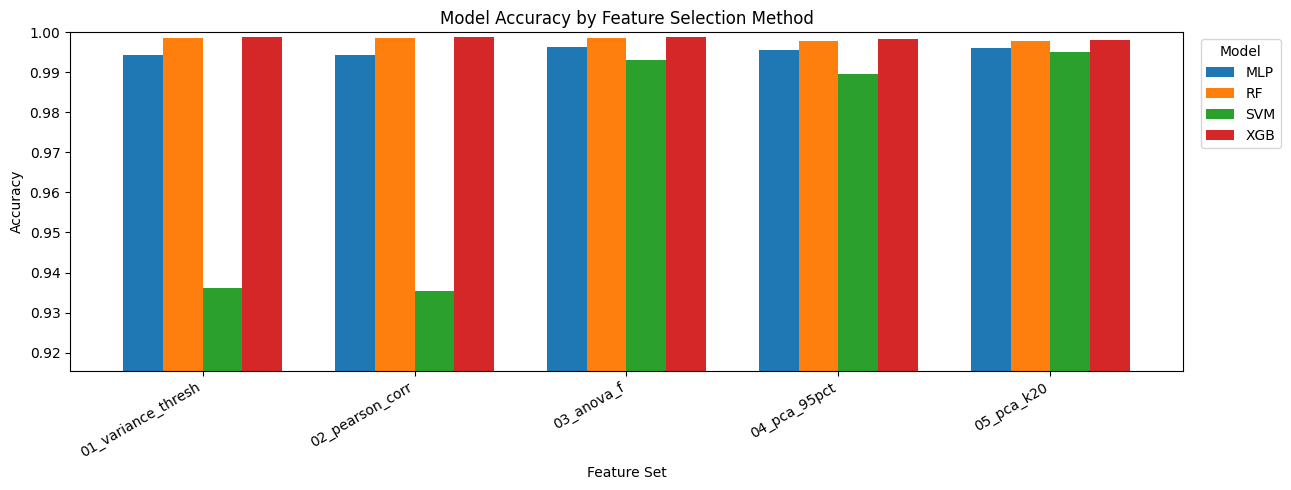

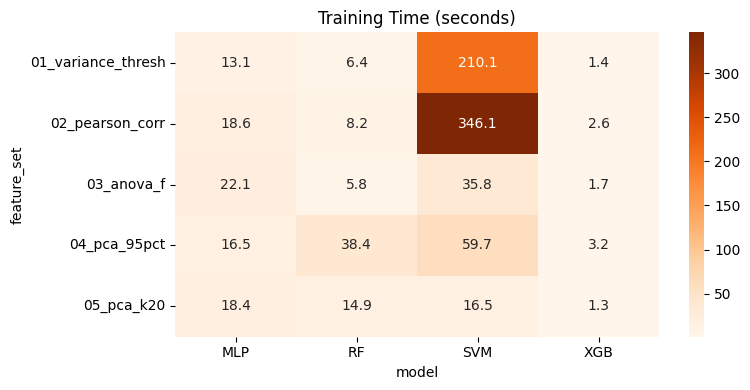

In [17]:
# ── Grouped bar chart: Accuracy per feature set × model
pivot = results_df.pivot_table(index="feature_set", columns="model", values="accuracy")
pivot = pivot.sort_values("RF", ascending=False)

ax = pivot.plot(kind="bar", figsize=(13, 5), width=0.75)
ax.set_title("Model Accuracy by Feature Selection Method")
ax.set_xlabel("Feature Set")
ax.set_ylabel("Accuracy")
ax.set_ylim(pivot.values.min() - 0.02, 1.0)
ax.legend(title="Model", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# ── Training time heatmap
heat_t = results_df.pivot_table(index="feature_set", columns="model", values="time_s")
plt.figure(figsize=(8, 4))
sns.heatmap(heat_t, annot=True, fmt=".1f", cmap="Oranges")
plt.title("Training Time (seconds)")
plt.tight_layout()
plt.show()

## 10. Best Model — Detailed Evaluation

In [18]:
best_row   = results_df.iloc[0]
best_fs    = best_row["feature_set"]
best_model = best_row["model"]
print(f"Best combination : {best_model}  on  {best_fs}")
print(f"Accuracy         : {best_row['accuracy']}")
print(f"F1-Weighted      : {best_row['f1_weighted']}")
print(f"ROC-AUC          : {best_row['roc_auc']}")

X_best_tr, X_best_te = feature_sets[best_fs]
X_best_tr = np.array(X_best_tr)
X_best_te = np.array(X_best_te)
m_best    = best_estimators[best_fs][best_model]

if best_model == "MLP":
    yp_best   = np.argmax(m_best.predict(X_best_te, verbose=0), axis=1)
    yprb_best = m_best.predict(X_best_te, verbose=0)
else:
    yp_best   = m_best.predict(X_best_te)
    yprb_best = m_best.predict_proba(X_best_te)

print("\nClassification Report:")
print(classification_report(y_test, yp_best, target_names=["normal", "attack"]))

Best combination : XGB  on  01_variance_thresh
Accuracy         : 0.9989
F1-Weighted      : 0.9989
ROC-AUC          : 1.0

Classification Report:
              precision    recall  f1-score   support

      normal       1.00      1.00      1.00     13469
      attack       1.00      1.00      1.00     11726

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00     25195
weighted avg       1.00      1.00      1.00     25195



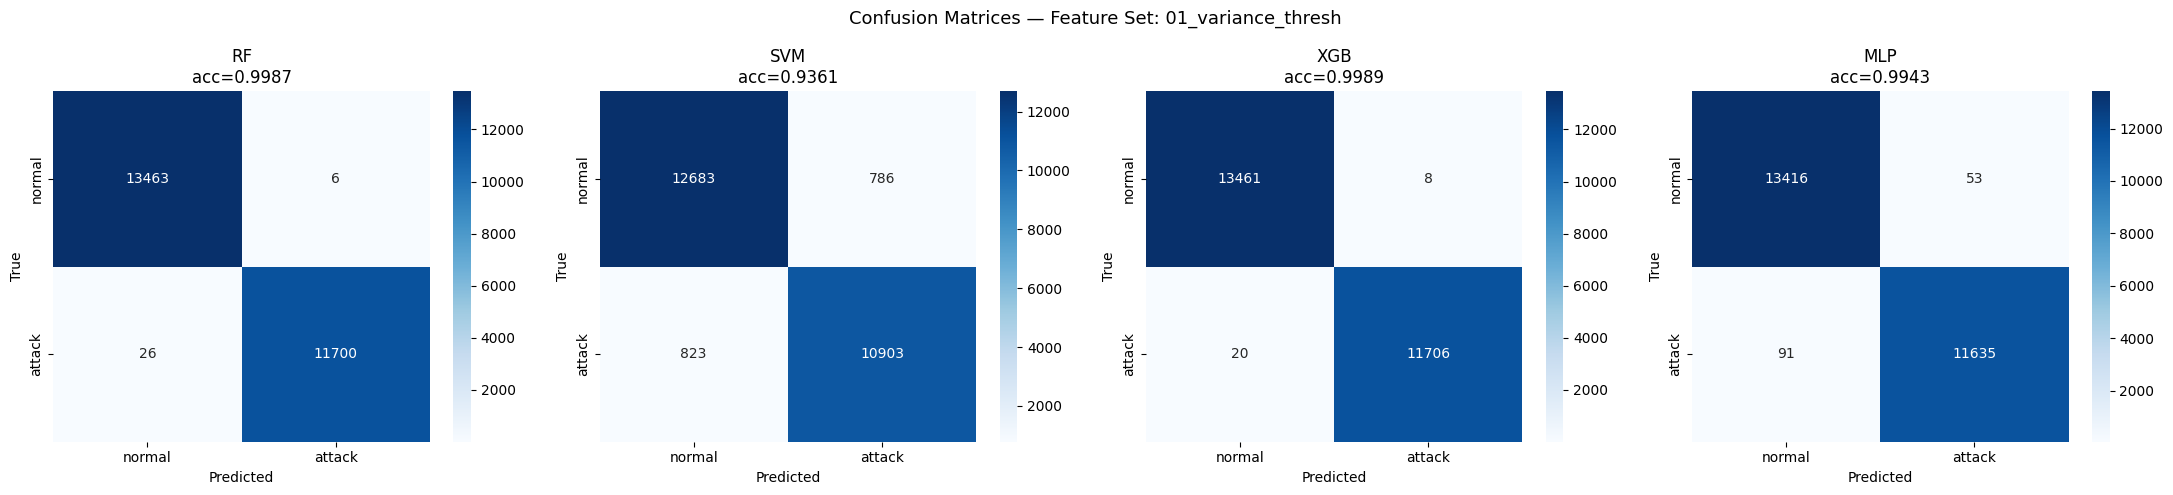

In [19]:
# Confusion matrices — all 4 models on the best feature set
model_names = ["RF", "SVM", "XGB", "MLP"]
fig, axes   = plt.subplots(1, 4, figsize=(22, 5))

for ax, mn in zip(axes, model_names):
    m = best_estimators[best_fs].get(mn)
    if m is None:
        ax.set_visible(False)
        continue
    if mn == "MLP":
        yp_m = np.argmax(m.predict(X_best_te, verbose=0), axis=1)
    else:
        yp_m = m.predict(X_best_te)
    cm = confusion_matrix(y_test, yp_m)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["normal","attack"], yticklabels=["normal","attack"])
    acc = accuracy_score(y_test, yp_m)
    ax.set_title(f"{mn}\nacc={acc:.4f}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.suptitle(f"Confusion Matrices — Feature Set: {best_fs}", fontsize=13)
plt.tight_layout()
plt.show()

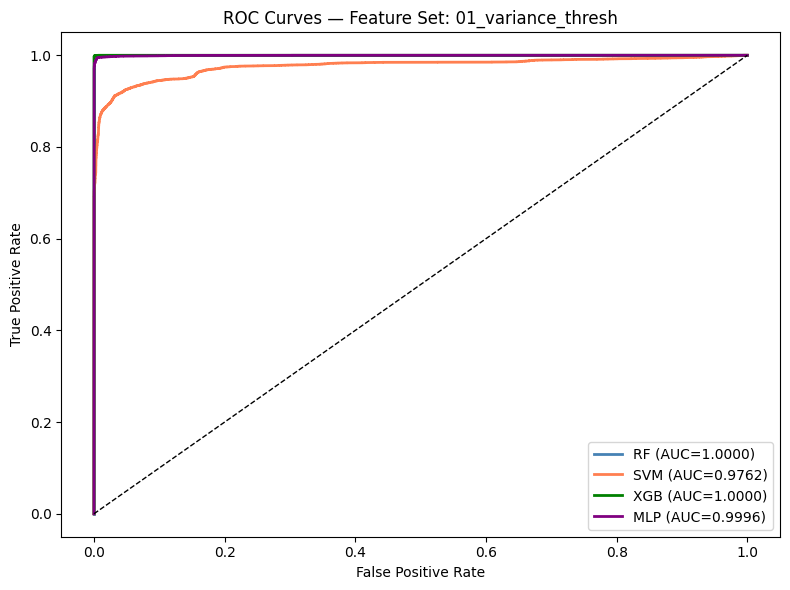

In [20]:
# ROC Curves — all 4 models on the best feature set
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(8, 6))
colors  = ["steelblue", "coral", "green", "purple"]

for mn, color in zip(model_names, colors):
    m = best_estimators[best_fs].get(mn)
    if m is None:
        continue
    if mn == "MLP":
        prob = m.predict(X_best_te, verbose=0)[:, 1]
    else:
        prob = m.predict_proba(X_best_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    ax.plot(fpr, tpr, label=f"{mn} (AUC={auc:.4f})", color=color, lw=2)

ax.plot([0,1],[0,1], "k--", lw=1)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title(f"ROC Curves — Feature Set: {best_fs}")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 11. GridSearchCV — Highest Accuracy Tuning

GridSearchCV with 5-fold StratifiedKFold is applied to **all 4 models** on the **top feature set** to find the highest accuracy configuration.

In [21]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Run GridSearch on the top-2 feature sets by accuracy
top2_fs = (results_df.groupby("feature_set")["accuracy"]
                     .max()
                     .nlargest(2)
                     .index.tolist())
print(f"GridSearchCV target feature sets: {top2_fs}")

# Search grids for each model
rf_grid = {
    "n_estimators" : [100, 200, 300],
    "max_depth"    : [10, 20, None],
    "max_features" : ["sqrt", "log2"],
}
svm_grid = {
    "C"     : [0.1, 1.0, 10.0],
    "gamma" : ["scale", "auto"],
}
xgb_grid = {
    "n_estimators"    : [100, 200],
    "max_depth"       : [4, 6, 8],
    "learning_rate"   : [0.05, 0.1, 0.2],
    "subsample"       : [0.7, 1.0],
}

gs_results = []
gs_best_models = {}

for fs_name in top2_fs:
    X_tr, X_te = feature_sets[fs_name]
    X_tr = np.array(X_tr)
    X_te = np.array(X_te)
    print(f"\n{'='*60}\nFeature Set: {fs_name}\n{'='*60}")

    # RF
    print("  [RF] GridSearchCV...")
    t0    = time.time()
    gs_rf = GridSearchCV(
        RandomForestClassifier(random_state=42, n_jobs=-1, class_weight="balanced"),
        rf_grid, scoring="accuracy", cv=cv, n_jobs=-1, refit=True, verbose=0
    )
    gs_rf.fit(X_tr, y_train)
    yp  = gs_rf.predict(X_te)
    met = evaluate(y_test, yp, gs_rf.predict_proba(X_te))
    elapsed = round(time.time() - t0, 2)
    print(f"  Best params: {gs_rf.best_params_}")
    print(f"  CV acc={gs_rf.best_score_:.4f}  Test acc={met['accuracy']}  f1={met['f1_weighted']}  ({elapsed}s)")
    gs_results.append({"feature_set": fs_name, "model": "RF_gs", "cv_score": round(gs_rf.best_score_,4), "time_s": elapsed, **met})
    gs_best_models[f"{fs_name}_RF"] = gs_rf

    # SVM (subsample for speed)
    print("  [SVM] GridSearchCV...")
    t0     = time.time()
    idx    = np.random.default_rng(42).choice(len(X_tr), min(SVM_MAX_ROWS, len(X_tr)), replace=False)
    gs_svm = GridSearchCV(
        SVC(kernel="rbf", degree=3, probability=True, random_state=42, class_weight="balanced"),
        svm_grid, scoring="accuracy", cv=cv, n_jobs=-1, refit=True, verbose=0
    )
    gs_svm.fit(X_tr[idx], y_train.iloc[idx])
    yp  = gs_svm.predict(X_te)
    met = evaluate(y_test, yp, gs_svm.predict_proba(X_te))
    elapsed = round(time.time() - t0, 2)
    print(f"  Best params: {gs_svm.best_params_}")
    print(f"  CV acc={gs_svm.best_score_:.4f}  Test acc={met['accuracy']}  f1={met['f1_weighted']}  ({elapsed}s)")
    gs_results.append({"feature_set": fs_name, "model": "SVM_gs", "cv_score": round(gs_svm.best_score_,4), "time_s": elapsed, **met})

    # XGB
    print("  [XGB] GridSearchCV...")
    t0     = time.time()
    gs_xgb = GridSearchCV(
        XGBClassifier(random_state=42, eval_metric="logloss", n_jobs=1, device=xgb_device),
        xgb_grid, scoring="accuracy", cv=cv, n_jobs=-1, refit=True, verbose=0
    )
    gs_xgb.fit(X_tr, y_train)
    yp  = gs_xgb.predict(X_te)
    met = evaluate(y_test, yp, gs_xgb.predict_proba(X_te))
    elapsed = round(time.time() - t0, 2)
    print(f"  Best params: {gs_xgb.best_params_}")
    print(f"  CV acc={gs_xgb.best_score_:.4f}  Test acc={met['accuracy']}  f1={met['f1_weighted']}  ({elapsed}s)")
    gs_results.append({"feature_set": fs_name, "model": "XGB_gs", "cv_score": round(gs_xgb.best_score_,4), "time_s": elapsed, **met})
    gs_best_models[f"{fs_name}_XGB"] = gs_xgb

print("\nGridSearchCV complete.")

GridSearchCV target feature sets: ['01_variance_thresh', '02_pearson_corr']

Feature Set: 01_variance_thresh
  [RF] GridSearchCV...
  Best params: {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 300}
  CV acc=0.9988  Test acc=0.9988  f1=0.9988  (631.64s)
  [SVM] GridSearchCV...
  Best params: {'C': 10.0, 'gamma': 'auto'}
  CV acc=0.9906  Test acc=0.9918  f1=0.9918  (1457.23s)
  [XGB] GridSearchCV...
  Best params: {'learning_rate': 0.2, 'max_depth': 8, 'n_estimators': 200, 'subsample': 1.0}
  CV acc=0.9989  Test acc=0.999  f1=0.999  (100.5s)

Feature Set: 02_pearson_corr
  [RF] GridSearchCV...
  Best params: {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 200}
  CV acc=0.9987  Test acc=0.9987  f1=0.9987  (714.42s)
  [SVM] GridSearchCV...
  Best params: {'C': 10.0, 'gamma': 'auto'}
  CV acc=0.9913  Test acc=0.9929  f1=0.9929  (1955.75s)
  [XGB] GridSearchCV...
  Best params: {'learning_rate': 0.2, 'max_depth': 6, 'n_estimators': 200, 'subsample': 1.0}
  CV acc=0.

In [22]:
gs_df = pd.DataFrame(gs_results).sort_values("accuracy", ascending=False).reset_index(drop=True)
print("GridSearchCV Results:")
display(gs_df[["feature_set","model","cv_score","accuracy","f1_weighted","roc_auc","time_s"]])

# Compare fixed-HP vs GridSearchCV
compare_models = ["RF","SVM","XGB"]
compare_df = results_df[results_df["model"].isin(compare_models) &
                        results_df["feature_set"].isin(top2_fs)].copy()
compare_df["variant"] = "fixed"
gs_compare = gs_df.copy()
gs_compare["variant"] = "grid_search"
gs_compare["model"]   = gs_compare["model"].str.replace("_gs", "")

combined = pd.concat([
    compare_df[["feature_set","model","variant","accuracy","f1_weighted"]],
    gs_compare[["feature_set","model","variant","accuracy","f1_weighted"]]
]).sort_values(["model","feature_set","variant"])

print("\nFixed HP vs GridSearchCV Comparison:")
display(combined)

GridSearchCV Results:


,feature_set,model,cv_score,accuracy,f1_weighted,roc_auc,time_s
0,01_variance_thresh,XGB_gs,0.9989,0.9990,0.9990,1.0000,100.50
1,02_pearson_corr,XGB_gs,0.9988,0.9989,0.9989,1.0000,146.83
2,01_variance_thresh,RF_gs,0.9988,0.9988,0.9988,1.0000,631.64
3,02_pearson_corr,RF_gs,0.9987,0.9987,0.9987,1.0000,714.42
4,02_pearson_corr,SVM_gs,0.9913,0.9929,0.9929,0.9990,1955.75
5,01_variance_thresh,SVM_gs,0.9906,0.9918,0.9918,0.9986,1457.23



Fixed HP vs GridSearchCV Comparison:


,feature_set,model,variant,accuracy,f1_weighted
3,01_variance_thresh,RF,fixed,0.9987,0.9987
2,01_variance_thresh,RF,grid_search,0.9988,0.9988
4,02_pearson_corr,RF,fixed,0.9985,0.9985
3,02_pearson_corr,RF,grid_search,0.9987,0.9987
18,01_variance_thresh,SVM,fixed,0.9361,0.9361
5,01_variance_thresh,SVM,grid_search,0.9918,0.9918
19,02_pearson_corr,SVM,fixed,0.9355,0.9355
4,02_pearson_corr,SVM,grid_search,0.9929,0.9929
0,01_variance_thresh,XGB,fixed,0.9989,0.9989
0,01_variance_thresh,XGB,grid_search,0.9990,0.9990


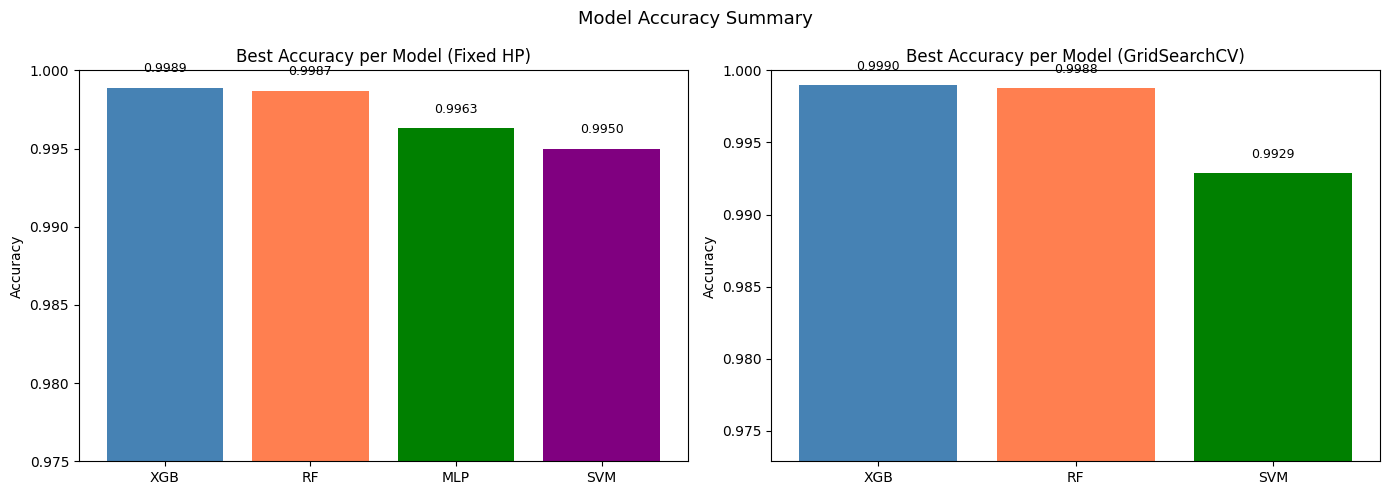

In [23]:
# ── Final summary bar chart: best accuracy per model (fixed vs GS)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: best accuracy per model across all feature sets
best_per_model = results_df.groupby("model")["accuracy"].max().sort_values(ascending=False)
axes[0].bar(best_per_model.index, best_per_model.values,
            color=["steelblue","coral","green","purple"][:len(best_per_model)])
axes[0].set_title("Best Accuracy per Model (Fixed HP)")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(best_per_model.min() - 0.02, 1.0)
for i, v in enumerate(best_per_model.values):
    axes[0].text(i, v + 0.001, f"{v:.4f}", ha="center", fontsize=9)

# Right: best accuracy per model (GridSearch)
best_gs = gs_df.copy()
best_gs["model"] = best_gs["model"].str.replace("_gs","")
best_gs_per_model = best_gs.groupby("model")["accuracy"].max().sort_values(ascending=False)
axes[1].bar(best_gs_per_model.index, best_gs_per_model.values,
            color=["steelblue","coral","green"][:len(best_gs_per_model)])
axes[1].set_title("Best Accuracy per Model (GridSearchCV)")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(best_gs_per_model.min() - 0.02, 1.0)
for i, v in enumerate(best_gs_per_model.values):
    axes[1].text(i, v + 0.001, f"{v:.4f}", ha="center", fontsize=9)

plt.suptitle("Model Accuracy Summary", fontsize=13)
plt.tight_layout()
plt.show()

In [26]:
# Save results to CSV
results_df.to_csv("results_fixed_hp_train+.csv",   index=False)
gs_df.to_csv("results_gridsearch_train+.csv",       index=False)
print("Saved: results_fixed_hp_train+.csv, results_gridsearch_train+.csv")

Saved: results_fixed_hp_train+.csv, results_gridsearch_train+.csv
